### Практическая 2

In [127]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [128]:
def f(x):
    """Функция f(x) = lg(x+5) - cos(x)"""
    return math.log10(x + 5) - math.cos(x)

--- Отделение корней ---


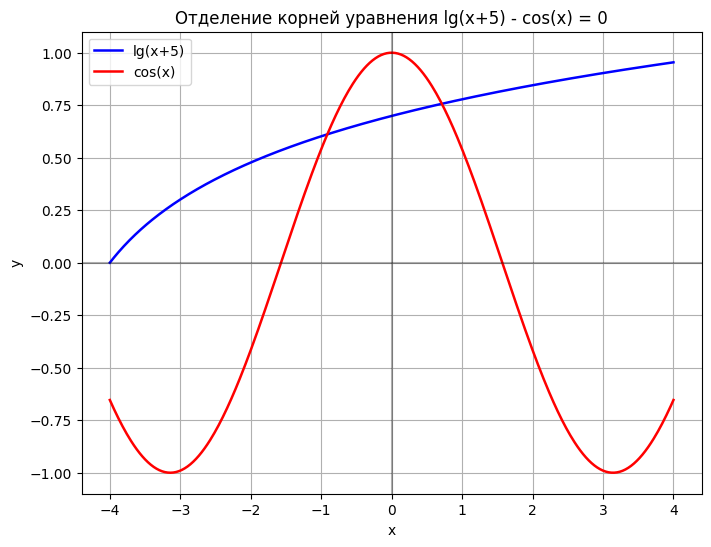

Корень на отрезке [-0.93; -0.91]
Корень на отрезке [0.71; 0.73]


In [129]:
print("--- Отделение корней ---")

x = np.linspace(-4, 4, 400)
y1 = np.log10(x + 5)
y2 = np.cos(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y1, label='lg(x+5)', color='blue', linewidth=1.8)
plt.plot(x, y2, label='cos(x)', color='red', linewidth=1.8)
plt.grid(True)
plt.legend()
plt.title('Отделение корней уравнения lg(x+5) - cos(x) = 0')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

for i in range(len(x)-1):
    if (y1[i]-y2[i])*(y1[i+1]-y2[i+1]) < 0:
        print(f"Корень на отрезке [{x[i]:.2f}; {x[i+1]:.2f}]")

In [130]:
print("--- Метод половинного деления ---")
a, b, eps, n = 0.6, 0.8, 0.001, 0

print(f"Начальный отрезок: [{a}, {b}]")
print(f"Точность: {eps}\n")

while b - a > eps:
    c = (a + b) / 2
    if f(a) * f(c) <= 0:
        b = c
    else:
        a = c
    n += 1

print(f"Корень:  x = {(a+b)/2:.6f}")
print(f"Количество итераций: {n}")

--- Метод половинного деления ---
Начальный отрезок: [0.6, 0.8]
Точность: 0.001

Корень:  x = 0.712109
Количество итераций: 8


### Практическая 3

In [131]:
def phi(x):
    """Новая итерационная формула: x_{n+1} = x_n + cos(x_n) - lg(x_n+5)"""
    return x + math.cos(x) - math.log10(x + 5)

print("--- Метод итераций ---")
x0 = 0.75
eps = 0.001
x = x0
n = 0

while True:
    x_new = phi(x)
    if abs(x_new - x) < eps:
        break
    x = x_new
    n += 1

print(f"Корень: x = {x:.6f}")
print(f"Количество итераций: {n}")

--- Метод итераций ---
Корень: x = 0.713062
Количество итераций: 3


### Практическая 4

In [132]:
def f_prime(x):
    """Производная функции"""
    return (1/(x+5*math.log(10))) + math.sin(x)

def f_double_prime(x):
    """Вторая производная функции"""
    return -(1/((x+5)**2 * math.log(10))) + math.cos(x)

In [133]:
print("--- Метод хорд ---")
a = 0.6
b = 0.8
eps = 0.001

fa = f(a)
fb = f(b)

if fa * f_double_prime(a) > 0:
    c = a
    x0 = b
    print(f"Неподвижная точка c = {c} (т.к. f(a)·f''(a) = {fa * f_double_prime(a):.6f} > 0)")
    print(f"Начальное приближение x0 = {x0}\n")
else:
    c = b
    x0 = a
    print(f"Неподвижная точка c = {c} (т.к. f(b)·f''(b) = {fb * f_double_prime(b):.6f} > 0)")
    print(f"Начальное приближение x0 = {x0}\n")

n = 0
x_curr = x0
x_fixed = c
f_fixed = f(x_fixed)

while True:
    f_curr = f(x_curr)
    x_new = x_curr - f_curr * (x_curr - x_fixed) / (f_curr - f_fixed)
    
    print(f"Итерация {n+1}: x = {x_new:.6f}, f(x) = {f(x_new):.6f}")
    
    if abs(x_new - x_curr) < eps:
        break
    
    x_curr = x_new
    n += 1

print(f"\nКорень: x = {x_new:.6f}")
print(f"Количество итераций: {n + 1}")

--- Метод хорд ---
Неподвижная точка c = 0.8 (т.к. f(b)·f''(b) = 0.045624 > 0)
Начальное приближение x0 = 0.6

Итерация 1: x = 0.707247, f(x) = -0.003727
Итерация 2: x = 0.712154, f(x) = -0.000156
Итерация 3: x = 0.712359, f(x) = -0.000007

Корень: x = 0.712359
Количество итераций: 3


In [134]:
print("--- Метод касательных (Ньютона) ---")

a, b = 0.6, 0.8

if f(a) * f_double_prime(a) > 0:
    x0 = a
    print(f"Начальное приближение x0 = {a} (т.к. f(a)·f''(a) > 0)")
elif f(b) * f_double_prime(b) > 0:
    x0 = b
    print(f"Начальное приближение x0 = {b} (т.к. f(b)·f''(b) > 0)")
else:
    x0 = (a + b) / 2
    print(f"Начальное приближение x0 = {x0} (середина отрезка)")

eps = 0.001
n = 1
x = x0

m = min(abs(f_prime(a)), abs(f_prime(b)))
print(f"m = min|f'(x)| = {m:.6f}\n")

print(f"Итерация {n}: x = {x:.6f}, f(x) = {f(x):.6f}")

while True:
    x_new = x - f(x) / f_prime(x)
    f_new = f(x_new)

    print(f"Итерация {n+1}: x = {x_new:.6f}, f(x) = {f_new:.6f}")

    x = x_new
    n += 1
    
    if abs(f_new) / m < eps:
        break

print(f"\nКорень: x = {x_new:.6f}")
print(f"Количество итераций: {n}")

--- Метод касательных (Ньютона) ---
Начальное приближение x0 = 0.8 (т.к. f(b)·f''(b) > 0)
m = min|f'(x)| = 0.647199

Итерация 1: x = 0.800000, f(x) = 0.066721
Итерация 2: x = 0.716449, f(x) = 0.002984
Итерация 3: x = 0.712408, f(x) = 0.000029

Корень: x = 0.712408
Количество итераций: 3
